In [1]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [2]:
df = pd.read_csv("C:/Users/preet/Desktop/ML/Datasets/loan_approval_dataset_lad.csv")
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Salary             1000 non-null   int64 
 2   Credit_Score       1000 non-null   int64 
 3   Loan_Amount        1000 non-null   int64 
 4   Loan_Term          1000 non-null   object
 5   Employment_Status  1000 non-null   object
 6   Residence_Type     1000 non-null   object
 7   Previous_Default   1000 non-null   object
 8   Loan_Approved      1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


<Axes: >

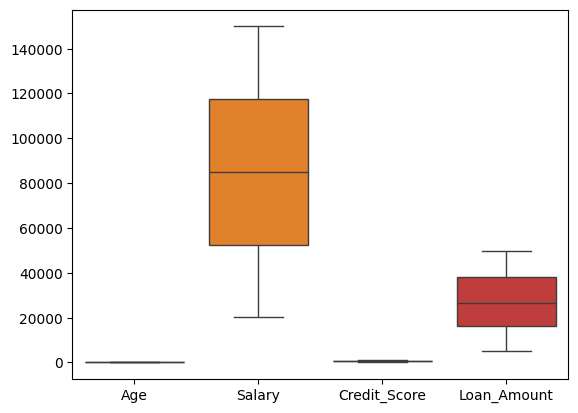

In [4]:
sns.boxplot(df)

In [5]:
df["Loan_Term"] = df["Loan_Term"].str.split().str[0]

In [6]:
df["Loan_Term"] = df["Loan_Term"].astype(int)

In [7]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24,Unemployed,Owned,No,No
4,25,28512,788,14528,12,Employed,Owned,No,No


In [8]:
x = df.drop(columns=["Loan_Approved"])
y = df["Loan_Approved"]

In [9]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, train_size=0.8, random_state=42)

In [10]:
xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 29 to 102
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                800 non-null    int64 
 1   Salary             800 non-null    int64 
 2   Credit_Score       800 non-null    int64 
 3   Loan_Amount        800 non-null    int64 
 4   Loan_Term          800 non-null    int64 
 5   Employment_Status  800 non-null    object
 6   Residence_Type     800 non-null    object
 7   Previous_Default   800 non-null    object
dtypes: int64(5), object(3)
memory usage: 56.2+ KB


In [11]:
cat = xtrain.select_dtypes(include="object").columns

In [12]:
encoder = OneHotEncoder(dtype = int ,sparse_output=False)

In [13]:
encoded = encoder.fit_transform(xtrain[cat])
xtrain[encoder.get_feature_names_out()] = encoded

In [14]:
xtrain = xtrain.drop(columns = ["Employment_Status","Residence_Type","Previous_Default"])

In [15]:
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)

In [16]:
model = LogisticRegression(max_iter=1000)

In [17]:
model.fit(xtrain,ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
xtrain_pred = model.predict(xtrain)

In [19]:
ytrain.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

In [28]:
con_m1 = confusion_matrix(ytrain,xtrain_pred)
con_m1

array([[204, 193],
       [173, 230]])

__Confusion Matrix__

    - Out of 800 values 434 are correctly predicted.
    - 366 are falsely predicted.

In [21]:
model.score(xtrain,ytrain)

0.5425

__Accuracy Score Conclusion__

    - Out of 800 samples only 54 % values are correctly predicted.
    - Accuracy score is 54 % as model is performing poor.

In [22]:
recall_score(ytrain, xtrain_pred, pos_label="Yes")

0.5707196029776674

__Recall Score Conclusion for 'Yes'__

    - Out of all actual 'Yes' labels 57 % labels are correctly predicted as 'Yes'.
    - 43 % labels are wrongly predicted as 'No'.

In [23]:
recall_score(ytrain, xtrain_pred, pos_label="No")

0.5138539042821159

__Recall Score Conclusion for 'No'__

    - Out of all actual 'No' labels 51 % labels are correctly predicted as 'No'.
    - 49 % labels are wrongly predicted as 'Yes'.

In [24]:
precision_score(ytrain, xtrain_pred, pos_label="Yes")

0.5437352245862884

__Precision Score Conclusion for 'Yes'__

    - Out of all predicted 'Yes' labels 54 % labels are correctly predicted as 'Yes'.
    - 46 % labels are wrongly predicted as 'Yes'.

In [25]:
precision_score(ytrain, xtrain_pred, pos_label="No")

0.5411140583554377

__Precision Score Conclusion for 'No'__

    - Out of all predicted 'No' labels 54 % labels are correctly predicted as 'No'.
    - 46 % labels are wrongly predicted as 'No'.

In [26]:
yes = f1_score(ytrain,xtrain_pred,pos_label="Yes")
no = f1_score(ytrain,xtrain_pred,pos_label="No")
print(yes, no, (yes+no)/2)

0.5569007263922519 0.5271317829457365 0.5420162546689942


__Here the f1 score for 'Yes' is 55 % as both recall score(57 %) and precision score(54 %) for 'Yes' are near to 55 %__

In [27]:
f1_score(ytrain,xtrain_pred,pos_label="No")

0.5271317829457365

__Here the f1 score for 'No' is 52 % as both recall score(51 %) and precision score(54 %) for 'No' are near to 52 %__